# 03 · Choosing parameters

All four methods use the 4 PCA components.

## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
DATA_DIR = "../data"
K_VALUES = range(2, 11)  

## 1. Load data

In [5]:
X = pd.read_csv(f"{DATA_DIR}/X_pca.csv")
print("Shape:", X.shape)

Shape: (12330, 4)


## 2. K-Means: metrics for k = 2 to 10

In [7]:
kmeans_rows = []

for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    kmeans_rows.append({
        "k": k,
        "inertia": model.inertia_,                                   # lower = tighter clusters (always falls)
        "silhouette": silhouette_score(X, labels),                   # higher is better (max 1)
        "davies_bouldin": davies_bouldin_score(X, labels),           # lower is better
        "calinski_harabasz": calinski_harabasz_score(X, labels),     # higher is better
        "smallest_cluster": np.bincount(labels).min(),
    })

kmeans_metrics = pd.DataFrame(kmeans_rows)
kmeans_metrics.round(3)

C:\Users\Raina Samanta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Raina Samanta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 1538, in _execute_child


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster
0,2,84333.874,0.348,1.237,5719.728,5977
1,3,54937.841,0.399,0.911,7687.698,841
2,4,38490.250,0.445,0.858,9070.314,824
3,5,28810.212,0.456,0.760,10122.968,797
4,6,24900.789,0.405,0.790,9756.017,731
5,7,22113.023,0.386,0.867,9413.291,491
6,8,19424.790,0.391,0.945,9427.889,487
7,9,17335.864,0.396,0.910,9428.248,386
8,10,16015.248,0.379,0.934,9183.879,284


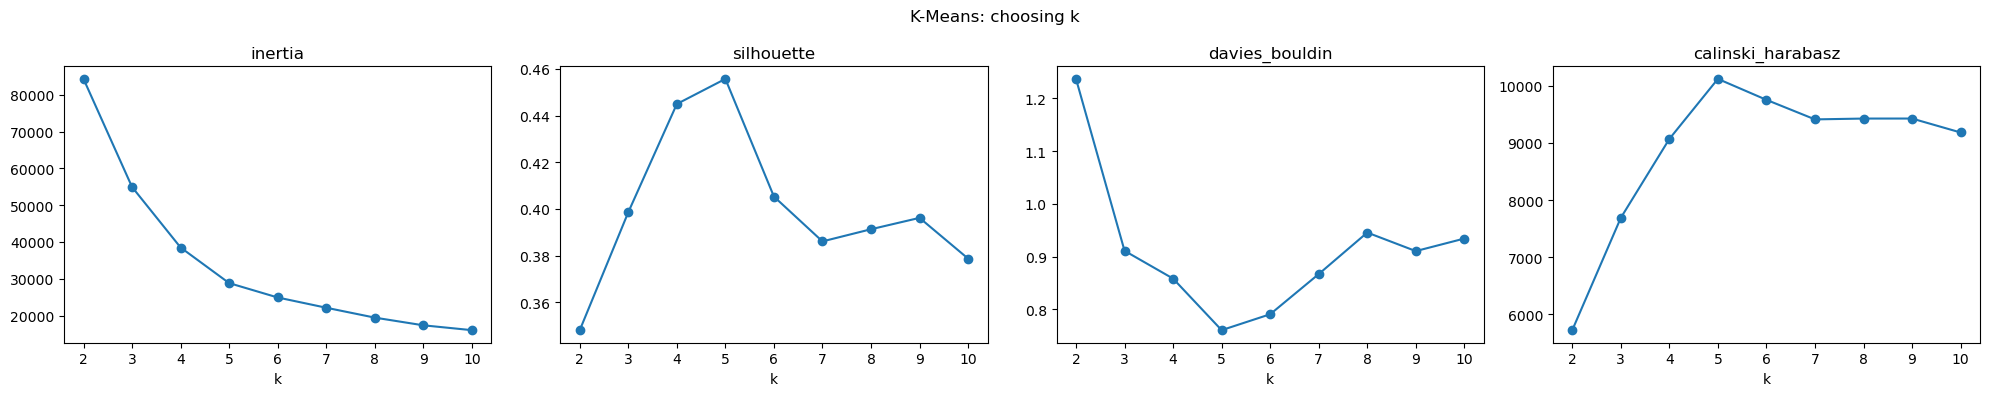

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
metric_names = ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz"]

for ax, metric in zip(axes, metric_names):
    ax.plot(kmeans_metrics["k"], kmeans_metrics[metric], marker="o")
    ax.set_title(metric)
    ax.set_xlabel("k")
    ax.set_xticks(list(K_VALUES))

plt.suptitle("K-Means: choosing k")
plt.tight_layout()
plt.show()

## 3. GMM: BIC for 2 to 10 components

In [10]:
# How many distinct points do the instant-bounce sessions (Bounce = Exit = 0.2) occupy in PCA space?
sessions = pd.read_csv(f"{DATA_DIR}/sessions_features.csv")
instant_bounce = (sessions["BounceRates"] == 0.2) & (sessions["ExitRates"] == 0.2)

print("Instant-bounce sessions:", instant_bounce.sum())
print("Distinct points they occupy:", len(X[instant_bounce].round(6).drop_duplicates()))

Instant-bounce sessions: 700
Distinct points they occupy: 19


In [11]:
# BIC with default settings vs with reg_covar = 0.01
# reg_covar adds a small number to each component's variance so no component can shrink to zero width
bic_rows = []

for k in K_VALUES:
    gmm_default = GaussianMixture(n_components=k, n_init=3, random_state=RANDOM_STATE)
    gmm_default.fit(X)

    gmm_reg = GaussianMixture(n_components=k, n_init=3, reg_covar=0.01, random_state=RANDOM_STATE)
    gmm_reg.fit(X)

    bic_rows.append({"k": k, "bic_default": gmm_default.bic(X), "bic_reg_covar_0.01": gmm_reg.bic(X)})

bic_table = pd.DataFrame(bic_rows)
bic_table["drop_from_previous"] = -bic_table["bic_reg_covar_0.01"].diff()
bic_table.round(0)

,k,bic_default,bic_reg_covar_0.01,drop_from_previous
0,2,84093.0,112940.0,NaN
1,3,105335.0,91968.0,20973.0
2,4,53919.0,84791.0,7177.0
3,5,30613.0,79006.0,5785.0
4,6,24072.0,76961.0,2045.0
5,7,19679.0,74449.0,2512.0
6,8,18100.0,73702.0,747.0
7,9,17385.0,72791.0,911.0
8,10,14720.0,73242.0,-451.0


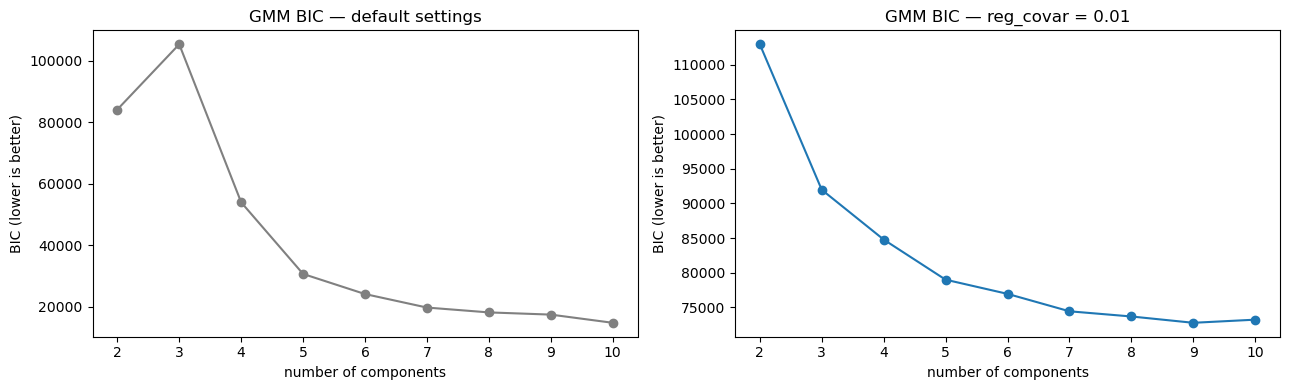

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(bic_table["k"], bic_table["bic_default"], marker="o", color="grey")
axes[0].set_title("GMM BIC — default settings")

axes[1].plot(bic_table["k"], bic_table["bic_reg_covar_0.01"], marker="o")
axes[1].set_title("GMM BIC — reg_covar = 0.01")

for ax in axes:
    ax.set_xlabel("number of components")
    ax.set_ylabel("BIC (lower is better)")
    ax.set_xticks(list(K_VALUES))

plt.tight_layout()
plt.show()

## 4. Agglomerative: 3,000-session sample

In [14]:
# Draw the random sample once and save it, so notebooks 04 and 05 use the same sessions
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = np.sort(rng.choice(len(X), size=3000, replace=False))
pd.DataFrame({"row": sample_idx}).to_csv(f"{DATA_DIR}/sample_idx.csv", index=False)

X_sample = X.iloc[sample_idx]
print("Sample shape:", X_sample.shape)

Sample shape: (3000, 4)


### 4a. Dendrograms for the four linkages

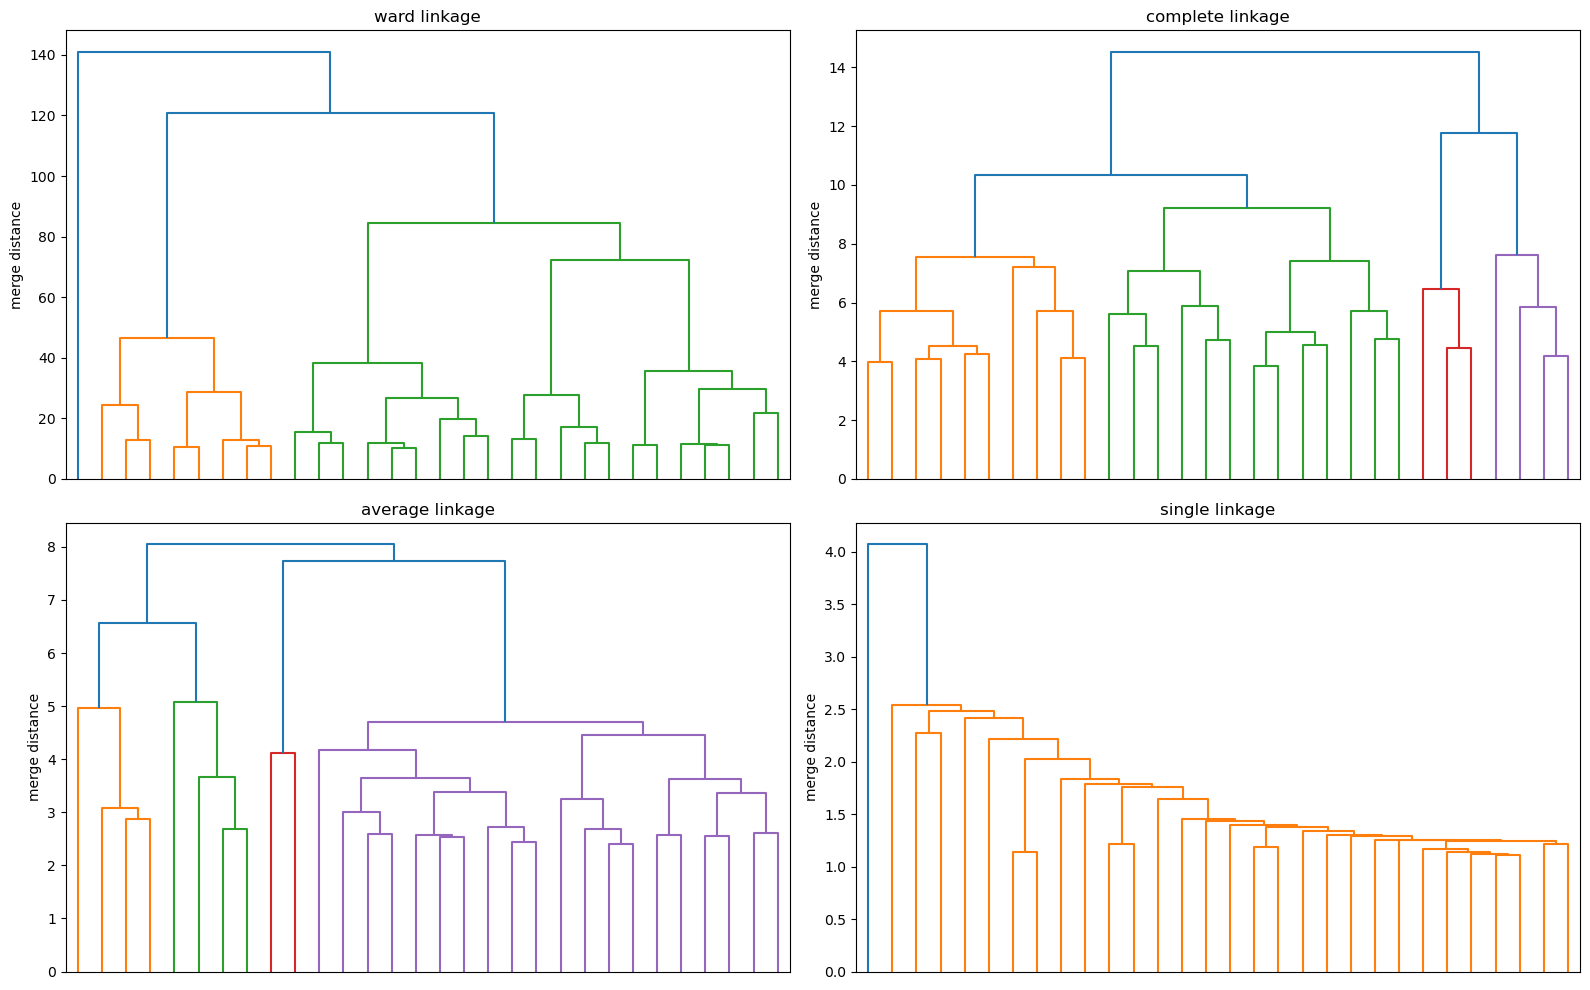

In [16]:
LINKAGES = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, method in zip(axes, LINKAGES):
    tree = linkage(X_sample, method=method)
    # truncate_mode="lastp" shows only the last 30 merges so the plot stays readable
    dendrogram(tree, truncate_mode="lastp", p=30, ax=ax, no_labels=True)
    ax.set_title(f"{method} linkage")
    ax.set_ylabel("merge distance")

plt.tight_layout()
plt.show()

### 4b. Metrics for k = 2 to 10, all four linkages

In [18]:
agglo_rows = []

for method in LINKAGES:
    for k in K_VALUES:
        labels = AgglomerativeClustering(n_clusters=k, linkage=method).fit_predict(X_sample)
        agglo_rows.append({
            "linkage": method,
            "k": k,
            "silhouette": silhouette_score(X_sample, labels),
            "davies_bouldin": davies_bouldin_score(X_sample, labels),
            "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
            "smallest_cluster": np.bincount(labels).min(),
            "largest_cluster": np.bincount(labels).max(),
        })

agglo_metrics = pd.DataFrame(agglo_rows)
agglo_metrics.round(3)

,linkage,k,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster
0,ward,2,0.573,0.352,1391.107,196,2804
1,ward,3,0.380,0.872,1824.135,196,1504
2,ward,4,0.424,0.930,1962.233,196,1300
3,ward,5,0.419,0.807,2198.727,196,1300
4,ward,6,0.352,0.867,2128.519,196,756
5,ward,7,0.359,0.928,2045.207,119,756
6,ward,8,0.365,0.907,2005.343,57,756
7,ward,9,0.359,0.929,1940.214,45,756
8,ward,10,0.348,0.916,1905.021,45,756
9,complete,2,0.511,0.828,1454.403,331,2669


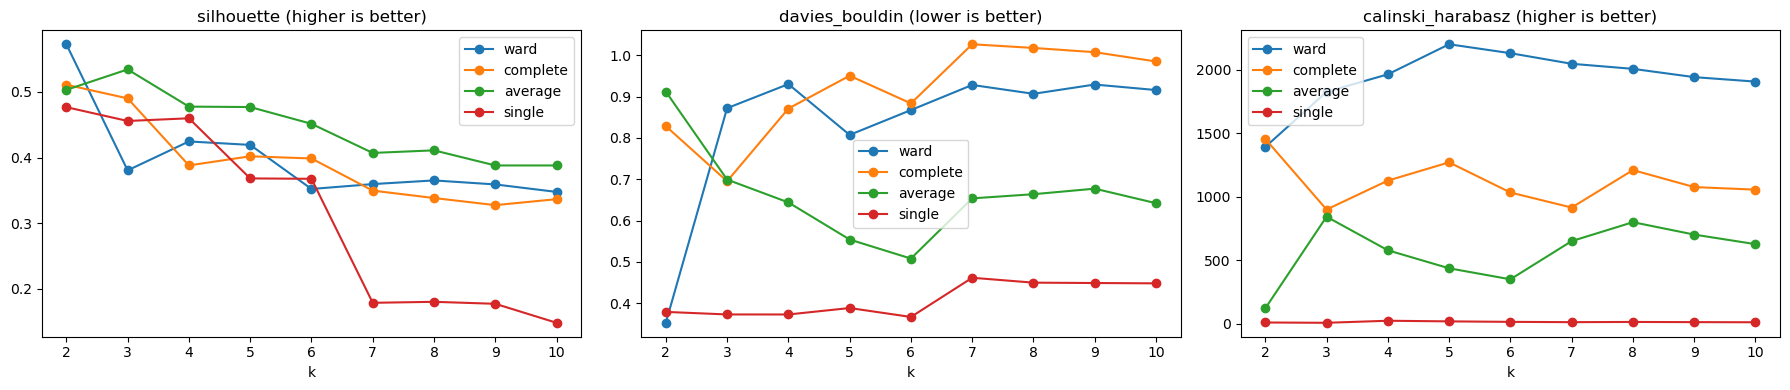

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for method in LINKAGES:
    part = agglo_metrics[agglo_metrics["linkage"] == method]
    axes[0].plot(part["k"], part["silhouette"], marker="o", label=method)
    axes[1].plot(part["k"], part["davies_bouldin"], marker="o", label=method)
    axes[2].plot(part["k"], part["calinski_harabasz"], marker="o", label=method)

axes[0].set_title("silhouette (higher is better)")
axes[1].set_title("davies_bouldin (lower is better)")
axes[2].set_title("calinski_harabasz (higher is better)")
for ax in axes:
    ax.set_xlabel("k")
    ax.set_xticks(list(K_VALUES))
    ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Cluster sizes at k = 5 for each linkage
for method in LINKAGES:
    labels = AgglomerativeClustering(n_clusters=5, linkage=method).fit_predict(X_sample)
    print(f"{method:9s}", sorted(np.bincount(labels).tolist(), reverse=True))

ward      [1300, 717, 520, 267, 196]
complete  [1972, 442, 307, 255, 24]
average   [2775, 198, 17, 7, 3]
single    [2990, 6, 2, 1, 1]


## 5. DBSCAN

### 5a. k-distance plot

In [23]:
MIN_SAMPLES = 2 * X.shape[1]   # rule of thumb: 2 x number of dimensions = 8

# Distance from each session to its 8th nearest neighbour (the session itself counts as the 1st)
neighbours = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = neighbours.kneighbors(X)
k_distance = np.sort(distances[:, -1])

In [24]:
# Find the "knee": the point on the curve furthest below a straight line from the first to the last point
positions = np.arange(len(k_distance))
straight_line = k_distance[0] + (k_distance[-1] - k_distance[0]) * positions / positions[-1]
knee = np.argmax(straight_line - k_distance)

print("Knee at position", knee, "-> eps ≈", round(k_distance[knee], 3))

Knee at position 11543 -> eps ≈ 0.632


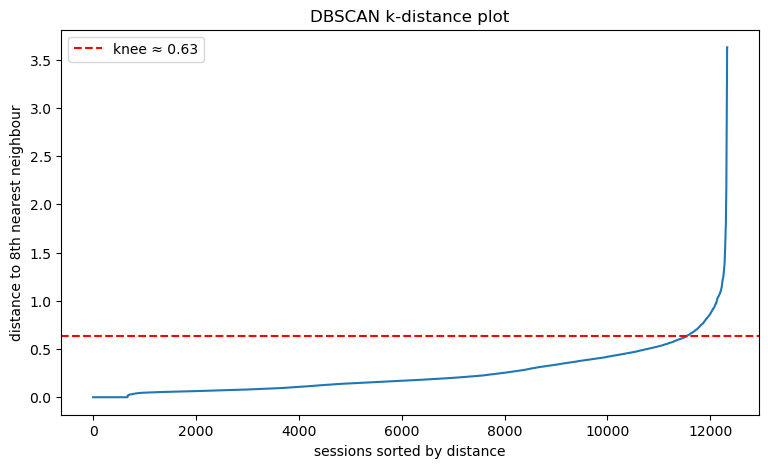

In [25]:
plt.figure(figsize=(9, 5))
plt.plot(k_distance)
plt.axhline(k_distance[knee], color="red", linestyle="--", label=f"knee ≈ {k_distance[knee]:.2f}")
plt.xlabel("sessions sorted by distance")
plt.ylabel(f"distance to {MIN_SAMPLES}th nearest neighbour")
plt.title("DBSCAN k-distance plot")
plt.legend()
plt.show()

### 5b. Small grid of eps and min_samples

In [27]:
dbscan_rows = []

for min_samples in [4, 8, 16]:
    for eps in [0.3, 0.4, 0.5, 0.6, 0.8, 1.0]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)

        is_noise = labels == -1
        n_clusters = len(set(labels[~is_noise]))

        # Silhouette only on non-noise points, and only if there are at least 2 clusters
        if n_clusters >= 2:
            sil = silhouette_score(X[~is_noise], labels[~is_noise])
        else:
            sil = np.nan

        sizes = sorted(np.bincount(labels[~is_noise]).tolist(), reverse=True)
        dbscan_rows.append({
            "min_samples": min_samples,
            "eps": eps,
            "clusters": n_clusters,
            "noise_share": is_noise.mean(),
            "silhouette_non_noise": sil,
            "largest_3_sizes": sizes[:3],
        })

dbscan_grid = pd.DataFrame(dbscan_rows)
dbscan_grid.round(3)

,min_samples,eps,clusters,noise_share,silhouette_non_noise,largest_3_sizes
0,4,0.3,80,0.164,-0.080,"[4573, 3897, 676]"
1,4,0.4,44,0.085,-0.295,"[8802, 1194, 676]"
2,4,0.5,20,0.043,-0.173,"[8902, 2135, 676]"
3,4,0.6,16,0.023,0.169,"[8946, 2318, 676]"
4,4,0.8,6,0.010,0.291,"[9658, 2515, 13]"
5,4,1.0,4,0.004,0.488,"[12241, 18, 16]"
6,8,0.3,29,0.260,-0.064,"[4566, 3605, 676]"
7,8,0.4,18,0.145,-0.217,"[8649, 838, 676]"
8,8,0.5,10,0.070,-0.047,"[8853, 1483, 676]"
9,8,0.6,5,0.041,0.409,"[8904, 2224, 676]"
